In [1]:
import pandas as pd
import numpy as np
import openpyxl

In [3]:
df = pd.read_excel('../data/processed/train_processed.xlsx')

In [4]:
df.head(5)

,V1,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V14_Ocasional,V17_Ativo,V17_Ausente,V17_Basico,V17_Conveniencia,V17_Economico,V17_Inativo,V17_Novo,V17_Premium,PERFORMANCE (var resposta)
0,563.101990,12,6,1264.109985,1.67665,944.123108,0.03750,0.19642,10,353,...,0,0,0,0,0,0,0,0,1,0
1,283.477509,15,2,408.279999,1.12000,317.494812,0.02437,0.13218,72,173,...,1,0,0,0,0,0,1,0,0,0
2,492.380005,365,1,0.000000,0.00000,0.000000,0.02437,0.00706,65,318,...,0,0,0,0,0,0,1,0,0,0
3,92.010002,365,0,0.000000,0.00000,0.000000,0.00000,0.00400,92,332,...,0,0,0,0,0,0,1,0,0,0
4,235.660004,365,0,0.000000,0.00000,0.000000,0.02437,-0.02804,92,157,...,0,0,0,0,0,0,1,0,0,0


In [5]:
df.isnull().sum()

V1                            0
V3                            0
V4                            0
V5                            0
V6                            0
V7                            0
V8                            0
V9                            0
V10                           0
V11                           0
V15                           0
V16                           0
V18                           0
V19                           0
V2_B                          0
V2_G                          0
V2_M                          0
V2_W                          0
V12_Ausente                   0
V12_Fiel                      0
V12_Inativo                   0
V12_Novo                      0
V12_Ocasional                 0
V13_Ausente                   0
V13_Fiel                      0
V13_Inativo                   0
V13_Novo                      0
V13_Ocasional                 0
V14_Ausente                   0
V14_Fiel                      0
V14_Inativo                   0
V14_Novo

In [6]:
X = df.drop('PERFORMANCE (var resposta)', axis=1)

y = df['PERFORMANCE (var resposta)']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14996, 41), (3749, 41), (14996,), (3749,))

In [9]:
print(y_train.value_counts(normalize=True)*100)

print(y_test.value_counts(normalize=True)*100)

PERFORMANCE (var resposta)
0    80.054681
1    19.945319
Name: proportion, dtype: float64
PERFORMANCE (var resposta)
0    80.048013
1    19.951987
Name: proportion, dtype: float64


In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [12]:
importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf.feature_importances_
})

importance = importance.sort_values(
    "Importancia",
    ascending=False
)

importance

,Variavel,Importancia
13,V19,0.139049
0,V1,0.119368
9,V11,0.108883
7,V9,0.107119
6,V8,0.057757
8,V10,0.056241
3,V5,0.047965
5,V7,0.047941
12,V18,0.046048
4,V6,0.045167


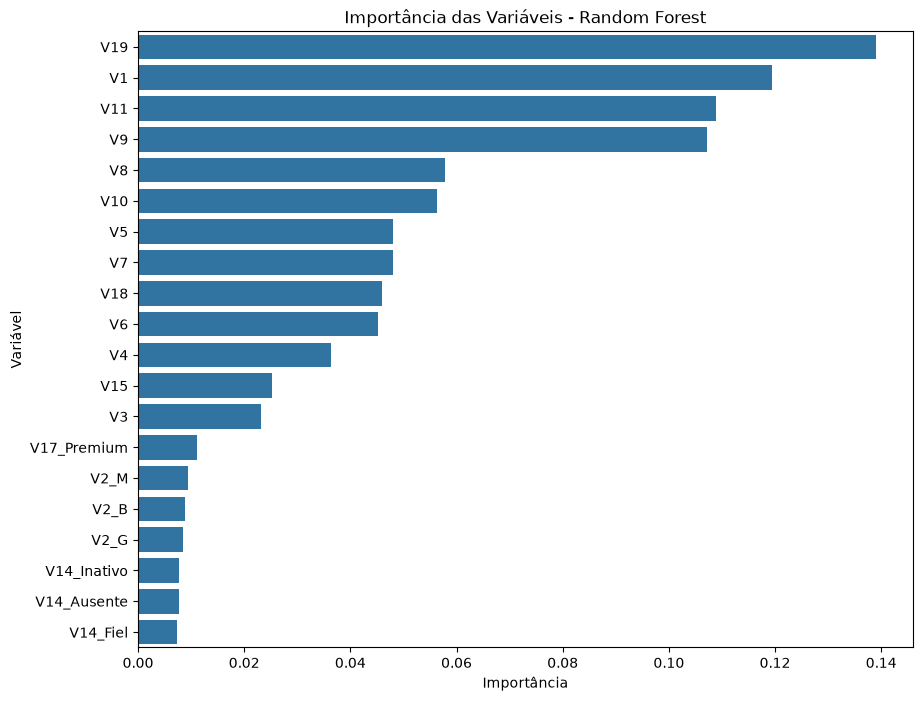

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance.head(20),
    x="Importancia",
    y="Variavel"
)

plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
df_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
df_scaled.head()


,V1,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V14_Novo,V14_Ocasional,V17_Ativo,V17_Ausente,V17_Basico,V17_Conveniencia,V17_Economico,V17_Inativo,V17_Novo,V17_Premium
0,-0.757490,-1.631192,-0.488834,-0.685569,-0.733304,-0.701836,-0.244196,0.347454,0.274654,-1.708258,...,-0.185913,-0.325673,-0.268729,2.588843,-0.167447,-0.336707,-0.212687,-0.710753,-0.149071,-0.612906
1,-0.483957,0.620411,1.040404,0.316454,0.555864,0.165779,-0.244196,-1.136924,-0.979204,-0.647849,...,-0.185913,-0.325673,-0.268729,-0.386273,-0.167447,-0.336707,-0.212687,-0.710753,-0.149071,1.631572
2,0.029712,0.620411,1.652100,1.911522,1.693364,2.532755,-0.264977,-0.864991,-1.059238,0.777077,...,-0.185913,-0.325673,-0.268729,-0.386273,-0.167447,-0.336707,-0.212687,-0.710753,-0.149071,1.631572
3,-0.347081,-1.676744,1.957947,1.630121,1.183593,0.925332,2.801406,1.964947,-1.112593,0.346286,...,-0.185913,-0.325673,-0.268729,-0.386273,-0.167447,-0.336707,-0.212687,-0.710753,-0.149071,1.631572
4,-0.679001,0.620411,0.581633,0.191359,1.001446,0.030963,-0.244196,-1.251338,-0.712426,1.183016,...,-0.185913,-0.325673,-0.268729,-0.386273,-0.167447,-0.336707,4.701736,-0.710753,-0.149071,-0.612906


In [16]:
df_scaled.describe()

,V1,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V14_Novo,V14_Ocasional,V17_Ativo,V17_Ausente,V17_Basico,V17_Conveniencia,V17_Economico,V17_Inativo,V17_Novo,V17_Premium
count,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,...,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04,1.499600e+04
mean,-8.623551e-17,9.476430e-18,-3.506279e-17,3.743190e-17,-6.467664e-17,7.296851e-17,5.875387e-17,2.748165e-17,7.344233e-17,-1.013978e-16,...,-1.516229e-17,-1.895286e-18,9.950252e-18,-9.476430e-19,-5.022508e-17,7.865437e-17,2.179579e-17,-7.107323e-18,-3.411515e-17,4.311776e-17
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,...,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00
min,-1.003715e+00,-1.748327e+00,-6.417581e-01,-6.855692e-01,-7.333038e-01,-7.018364e-01,-7.401388e-01,-1.276541e+00,-1.112593e+00,-2.147335e+00,...,-1.859130e-01,-3.256729e-01,-2.687286e-01,-3.862730e-01,-1.674475e-01,-3.367068e-01,-2.126874e-01,-7.107525e-01,-1.490712e-01,-6.129059e-01
25%,-6.690282e-01,-1.273278e+00,-6.417581e-01,-6.855692e-01,-7.333038e-01,-7.018364e-01,-2.441964e-01,-9.765297e-01,-9.525264e-01,-6.975552e-01,...,-1.859130e-01,-3.256729e-01,-2.687286e-01,-3.862730e-01,-1.674475e-01,-3.367068e-01,-2.126874e-01,-7.107525e-01,-1.490712e-01,-6.129059e-01
50%,-3.087919e-01,6.204107e-01,-3.359104e-01,-2.615133e-01,-2.306185e-01,-3.207617e-01,-2.441964e-01,-2.209048e-02,-4.189697e-01,3.711392e-01,...,-1.859130e-01,-3.256729e-01,-2.687286e-01,-3.862730e-01,-1.674475e-01,-3.367068e-01,-2.126874e-01,-7.107525e-01,-1.490712e-01,-6.129059e-01
75%,3.432399e-01,6.204107e-01,1.228612e-01,3.724569e-01,2.377332e-01,3.730704e-01,-2.441964e-01,8.289364e-01,1.341767e+00,7.273707e-01,...,-1.859130e-01,-3.256729e-01,-2.687286e-01,-3.862730e-01,-1.674475e-01,-3.367068e-01,-2.126874e-01,1.406960e+00,-1.490712e-01,1.631572e+00
max,1.862171e+01,6.204107e-01,1.036876e+01,3.241046e+01,1.064170e+01,2.303939e+01,6.588418e+00,2.546417e+00,1.341767e+00,2.293132e+00,...,5.378860e+00,3.070566e+00,3.721226e+00,2.588843e+00,5.972021e+00,2.969943e+00,4.701736e+00,1.406960e+00,6.708204e+00,1.631572e+00


In [20]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [19]:
logistic = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [21]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

,learning_rate,0.05
,n_estimators,300
,class_weight,'balanced'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [23]:
y_pred_logistic = logistic.predict(X_test_scaled)
y_prob_logistic = logistic.predict_proba(X_test_scaled)[:, 1]

In [24]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [25]:
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

In [26]:
models = {
    "Logistic Regression": y_pred_logistic,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm
}

probabilities = {
    "Logistic Regression": y_prob_logistic,
    "XGBoost": y_prob_xgb,
    "LightGBM": y_prob_lgbm
}

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [28]:
def evaluate_model(y_true, y_pred, y_prob):
    auc = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": auc,
        "Gini": 2 * auc - 1
    }

In [29]:
results = []

for name in models:

    metrics = evaluate_model(
        y_test,
        models[name],
        probabilities[name]
    )

    metrics["Modelo"] = name

    results.append(metrics)

In [30]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "Gini"
    ]
]

results_df.sort_values(
    "AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,AUC,Gini
1,XGBoost,0.803948,0.540373,0.116310,0.191419,0.715304,0.430609
2,LightGBM,0.697786,0.348544,0.592246,0.438831,0.712553,0.425106
0,Logistic Regression,0.649773,0.315721,0.647059,0.424375,0.711437,0.422873


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

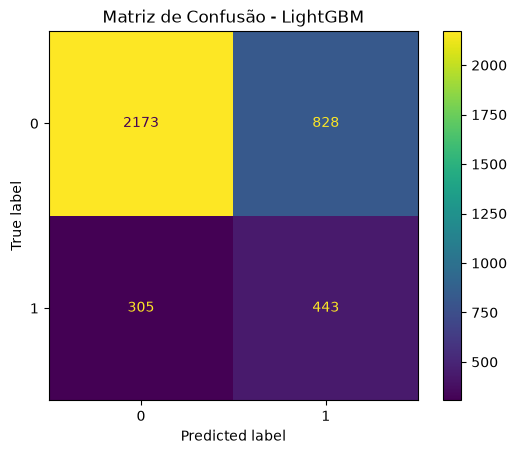

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgbm
)

plt.title("Matriz de Confusão - LightGBM")
plt.show()

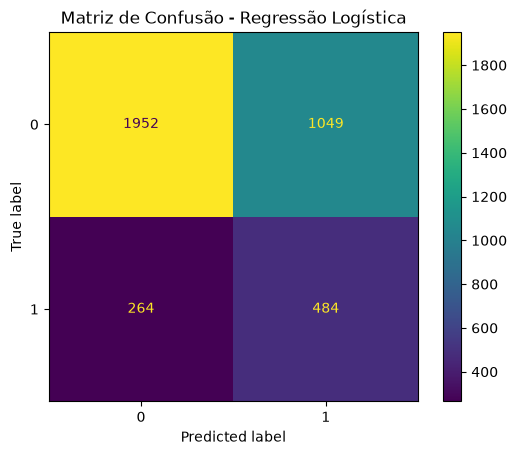

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

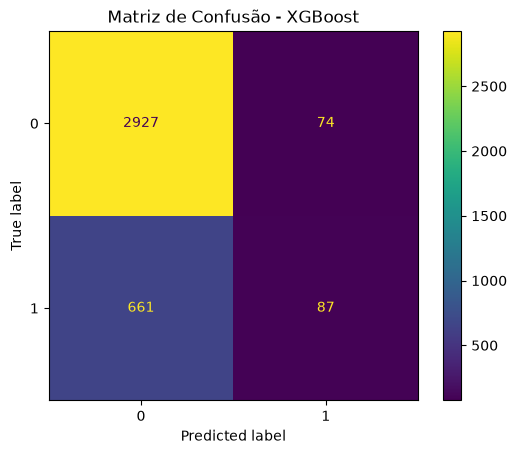

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("Matriz de Confusão - XGBoost")
plt.show()

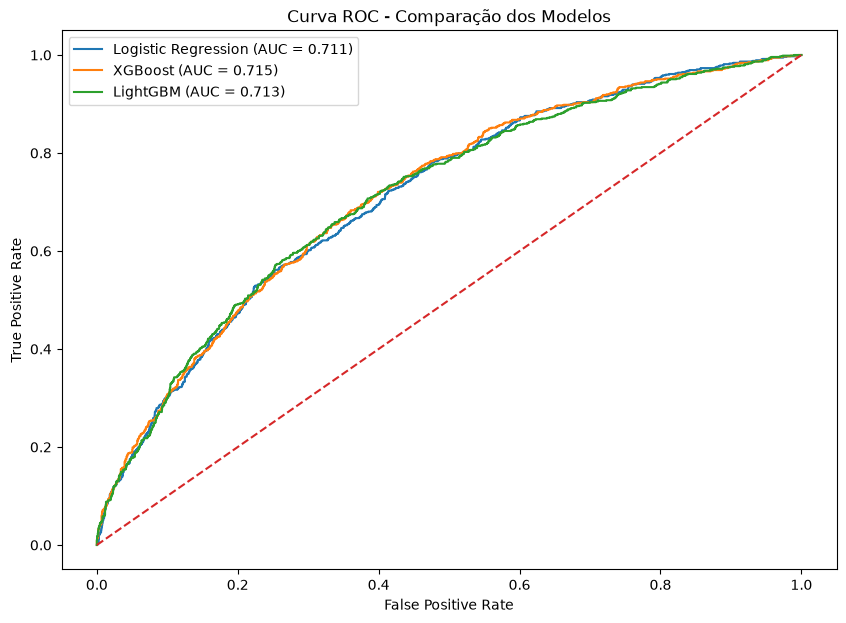

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparação dos Modelos")
plt.legend()
plt.show()

In [36]:
import numpy as np

def calculate_ks(y_true, y_prob):
    data = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    })

    data = data.sort_values(
        "y_prob",
        ascending=False
    )

    data["bad"] = (data["y_true"] == 1).astype(int)
    data["good"] = (data["y_true"] == 0).astype(int)

    data["cum_bad"] = data["bad"].cumsum() / data["bad"].sum()
    data["cum_good"] = data["good"].cumsum() / data["good"].sum()

    data["ks"] = abs(
        data["cum_bad"] - data["cum_good"]
    )

    return data["ks"].max()

In [37]:
ks_results = {}

for name, y_prob in probabilities.items():
    ks_results[name] = calculate_ks(
        y_test,
        y_prob
    )

ks_results

{'Logistic Regression': np.float64(0.3092480759532919),
 'XGBoost': np.float64(0.32294181796798566),
 'LightGBM': np.float64(0.32301398642520235)}

In [38]:
results_df["KS"] = results_df["Modelo"].map(ks_results)

results_df = results_df[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "Gini",
        "KS"
    ]
]

results_df.sort_values(
    "AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,AUC,Gini,KS
1,XGBoost,0.803948,0.540373,0.116310,0.191419,0.715304,0.430609,0.322942
2,LightGBM,0.697786,0.348544,0.592246,0.438831,0.712553,0.425106,0.323014
0,Logistic Regression,0.649773,0.315721,0.647059,0.424375,0.711437,0.422873,0.309248


In [39]:
feature_importance_lgbm = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
})

feature_importance_lgbm = feature_importance_lgbm.sort_values(
    "Importance",
    ascending=False
)

feature_importance_lgbm.head(20)

,Feature,Importance
0,V1,1048
9,V11,1042
7,V9,970
13,V19,928
12,V18,683
8,V10,661
3,V5,586
6,V8,551
4,V6,540
5,V7,522


In [41]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    "Importance",
    ascending=False
)

feature_importance_xgb.head(20)

,Feature,Importance
40,V17_Premium,0.077102
25,V13_Inativo,0.069028
13,V19,0.052355
8,V10,0.041469
20,V12_Inativo,0.033458
2,V4,0.030421
6,V8,0.026121
38,V17_Inativo,0.025997
0,V1,0.024249
5,V7,0.024136


In [43]:
from sklearn.inspection import permutation_importance

perm_lgbm = permutation_importance(
    lgbm,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [44]:
permutation_lgbm = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance_Mean": perm_lgbm.importances_mean,
    "Importance_Std": perm_lgbm.importances_std
})

permutation_lgbm = permutation_lgbm.sort_values(
    "Importance_Mean",
    ascending=False
)

permutation_lgbm.head(20)

,Feature,Importance_Mean,Importance_Std
13,V19,0.124265,0.003554
0,V1,0.066286,0.001800
9,V11,0.055462,0.001655
7,V9,0.046326,0.001064
6,V8,0.043878,0.002105
8,V10,0.037890,0.001526
12,V18,0.033843,0.001077
4,V6,0.025906,0.000613
3,V5,0.025283,0.000631
5,V7,0.018045,0.000744


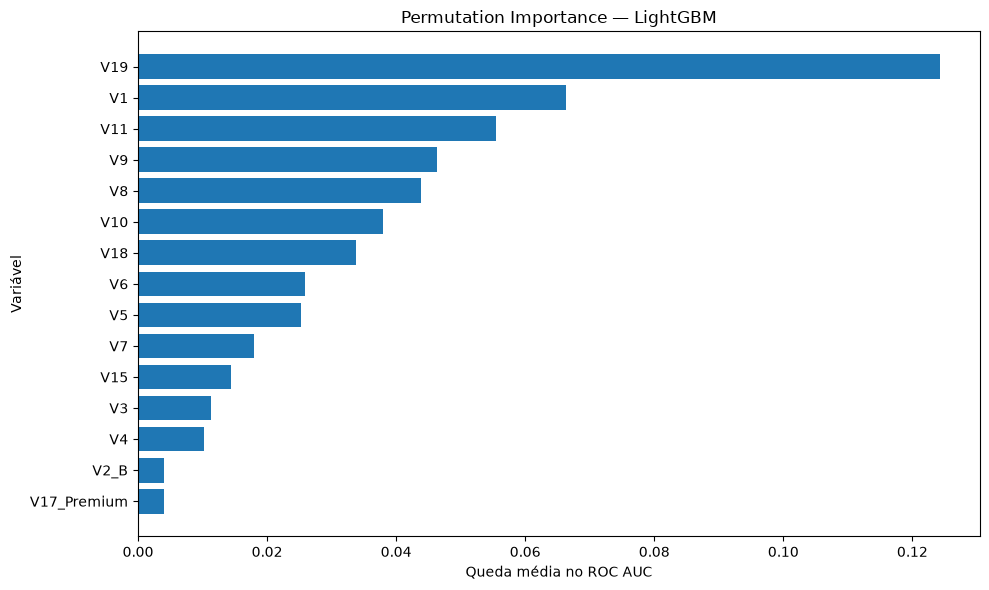

In [75]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_lgbm["Feature"].head(15)[::-1],
    permutation_lgbm["Importance_Mean"].head(15)[::-1]
)

plt.xlabel("Queda média no ROC AUC")
plt.ylabel("Variável")
plt.title("Permutation Importance — LightGBM")

plt.tight_layout()
plt.show()

In [46]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [47]:
permutation_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance_Mean": perm_xgb.importances_mean,
    "Importance_Std": perm_xgb.importances_std
})

permutation_xgb = permutation_xgb.sort_values(
    "Importance_Mean",
    ascending=False
)

permutation_xgb.head(20)

,Feature,Importance_Mean,Importance_Std
13,V19,0.115112,0.003675
0,V1,0.052930,0.001351
9,V11,0.043762,0.001320
7,V9,0.037630,0.000885
6,V8,0.034926,0.001876
8,V10,0.028270,0.001431
4,V6,0.021593,0.000582
3,V5,0.020934,0.000844
12,V18,0.020224,0.000689
5,V7,0.016560,0.000518


In [49]:
logistic_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic.coef_[0]
})

logistic_importance["Abs_Coefficient"] = (
    logistic_importance["Coefficient"].abs()
)

logistic_importance = logistic_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

logistic_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
13,V19,-0.535611,0.535611
38,V17_Inativo,0.322558,0.322558
40,V17_Premium,-0.288979,0.288979
8,V10,0.277460,0.277460
20,V12_Inativo,-0.275131,0.275131
7,V9,-0.246015,0.246015
9,V11,-0.223786,0.223786
0,V1,-0.197393,0.197393
5,V7,-0.171587,0.171587
19,V12_Fiel,0.169381,0.169381


In [50]:
top_lgbm = set(permutation_lgbm.head(20)["Feature"])
top_xgb = set(permutation_xgb.head(20)["Feature"])
top_logistic = set(logistic_importance.head(20)["Feature"])

common_features = sorted(top_lgbm.intersection(top_xgb, top_logistic))

common_features

['V1',
 'V10',
 'V11',
 'V17_Premium',
 'V18',
 'V19',
 'V2_B',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9']

In [51]:
selected_features = [
    "V1",
    "V10",
    "V11",
    "V17_Premium",
    "V18",
    "V19",
    "V2_B",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9"
]
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]



In [52]:
X_train_reduced.shape, X_test_reduced.shape

((14996, 12), (3749, 12))

In [53]:
X_train_reduced.head()

,V1,V10,V11,V17_Premium,V18,V19,V2_B,V5,V6,V7,V8,V9
9582,72.889999,52,53,0,0.00000,42,0,0.000000,0.00000,0.000000,0.02437,0.10481
5023,152.542343,5,181,1,0.52727,66,0,786.909973,2.72000,414.915192,0.02437,-0.04361
1513,302.121552,2,353,1,0.75843,52,0,2039.550049,5.12000,1546.862427,0.02325,-0.01642
14654,192.400375,0,301,1,0.42789,36,1,1818.560059,4.04444,778.152649,0.18852,0.26654
17798,95.746002,15,402,0,0.50887,50,0,688.669983,3.66013,350.442871,0.02437,-0.05505


In [54]:
scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler_reduced.transform(
    X_test_reduced
)

In [55]:
logistic_reduced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_reduced.fit(
    X_train_reduced_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [56]:
xgb_reduced = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_reduced.fit(
    X_train_reduced,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [57]:
lgbm_reduced = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_reduced.fit(
    X_train_reduced,
    y_train
)

,learning_rate,0.05
,n_estimators,300
,class_weight,'balanced'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [58]:
y_pred_logistic_reduced = logistic_reduced.predict(
    X_test_reduced_scaled
)

y_prob_logistic_reduced = logistic_reduced.predict_proba(
    X_test_reduced_scaled
)[:, 1]

y_pred_xgb_reduced = xgb_reduced.predict(
    X_test_reduced
)

y_prob_xgb_reduced = xgb_reduced.predict_proba(
    X_test_reduced
)[:, 1]

y_pred_lgbm_reduced = lgbm_reduced.predict(
    X_test_reduced
)

y_prob_lgbm_reduced = lgbm_reduced.predict_proba(
    X_test_reduced
)[:, 1]

In [59]:
reduced_results = []

reduced_models = {
    "Logistic Regression": (
        y_pred_logistic_reduced,
        y_prob_logistic_reduced
    ),
    "XGBoost": (
        y_pred_xgb_reduced,
        y_prob_xgb_reduced
    ),
    "LightGBM": (
        y_pred_lgbm_reduced,
        y_prob_lgbm_reduced
    )
}

In [60]:
for name, (y_pred, y_prob) in reduced_models.items():

    metrics = evaluate_model(
        y_test,
        y_pred,
        y_prob
    )

    metrics["Modelo"] = name

    reduced_results.append(metrics)

In [61]:
reduced_results_df = pd.DataFrame(reduced_results)

reduced_results_df["KS"] = reduced_results_df["Modelo"].map({
    "Logistic Regression": calculate_ks(
        y_test,
        y_prob_logistic_reduced
    ),
    "XGBoost": calculate_ks(
        y_test,
        y_prob_xgb_reduced
    ),
    "LightGBM": calculate_ks(
        y_test,
        y_prob_lgbm_reduced
    )
})

reduced_results_df = reduced_results_df[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "Gini",
        "KS"
    ]
]

reduced_results_df.sort_values(
    "AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,AUC,Gini,KS
1,XGBoost,0.805281,0.557692,0.116310,0.192478,0.711885,0.423771,0.314603
0,Logistic Regression,0.646306,0.314744,0.656417,0.425477,0.706574,0.413147,0.312628
2,LightGBM,0.698853,0.349407,0.590909,0.439146,0.704781,0.409563,0.329538


In [62]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(0.10, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_lgbm_reduced >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.281942,0.213612,0.969251,0.350072
1,0.15,0.350760,0.226831,0.935829,0.365154
2,0.20,0.409976,0.239872,0.902406,0.379001
3,0.25,0.462790,0.250394,0.848930,0.386724
4,0.30,0.512403,0.263365,0.803476,0.396700
5,0.35,0.566818,0.282738,0.762032,0.412446
6,0.40,0.610830,0.299718,0.711230,0.421720
7,0.45,0.656975,0.326227,0.675134,0.439895
8,0.50,0.698853,0.349407,0.590909,0.439146
9,0.55,0.729795,0.369971,0.504011,0.426712


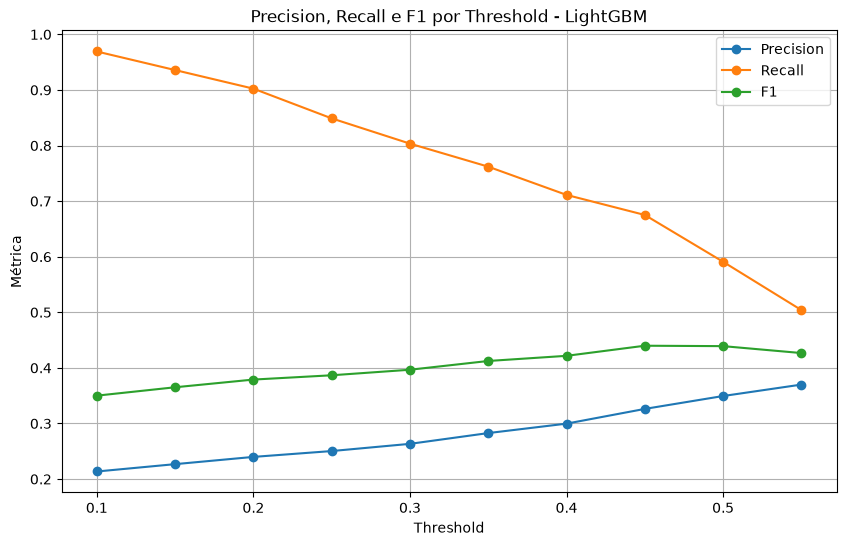

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por Threshold - LightGBM")
plt.legend()
plt.grid()

plt.show()

In [64]:
thresholds = np.arange(0.10, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb_reduced >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.460656,0.254054,0.879679,0.394248
1,0.15,0.576154,0.286873,0.756684,0.416024
2,0.20,0.662043,0.324544,0.641711,0.431073
3,0.25,0.723660,0.366913,0.530749,0.433880
4,0.30,0.754068,0.391791,0.421123,0.405928
5,0.35,0.777274,0.425894,0.334225,0.374532
6,0.40,0.792478,0.463235,0.252674,0.326990
7,0.45,0.798346,0.483740,0.159091,0.239437
8,0.50,0.805281,0.557692,0.116310,0.192478
9,0.55,0.803948,0.582278,0.061497,0.111245


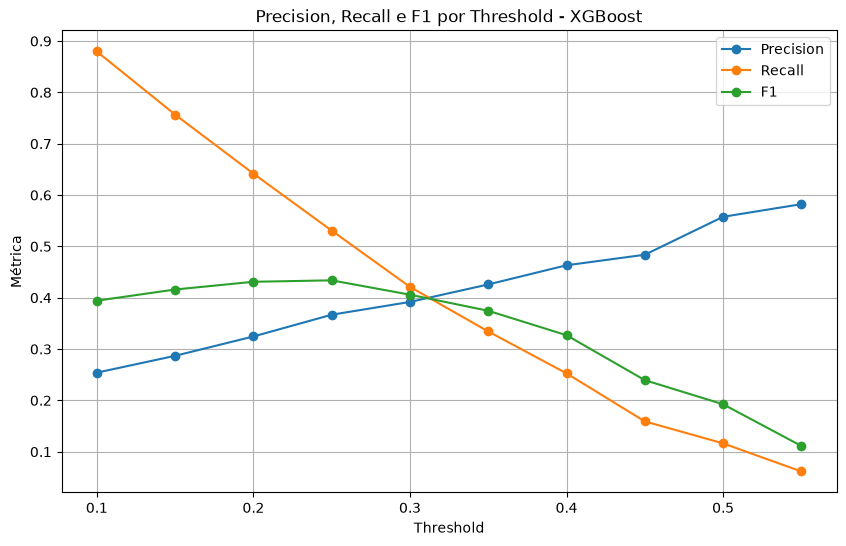

In [65]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por Threshold - XGBoost")
plt.legend()
plt.grid()

plt.show()

In [66]:
thresholds = np.arange(0.10, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_logistic_reduced >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.204321,0.200161,0.997326,0.333408
1,0.15,0.231795,0.205362,0.993316,0.340357
2,0.20,0.278741,0.214536,0.982620,0.352180
3,0.25,0.338224,0.226397,0.958556,0.366284
4,0.30,0.400907,0.239750,0.922460,0.380585
5,0.35,0.471859,0.258052,0.878342,0.398907
6,0.40,0.536943,0.276268,0.815508,0.412720
7,0.45,0.596426,0.296434,0.744652,0.424058
8,0.50,0.646306,0.314744,0.656417,0.425477
9,0.55,0.694585,0.340562,0.566845,0.425489


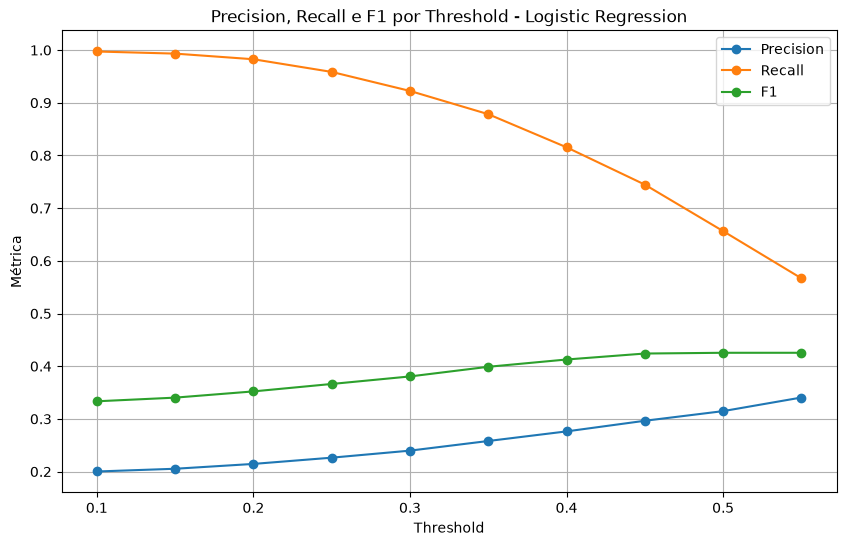

In [67]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por Threshold - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

In [71]:
X_final = df[selected_features]
y_final = df["PERFORMANCE (var resposta)"]

lgbm_final = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_final.fit(
    X_final,
    y_final
)

,learning_rate,0.05
,n_estimators,300
,class_weight,'balanced'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [72]:
import joblib

joblib.dump(
    lgbm_final,
    "../models/lightgbm_final.pkl"
)

joblib.dump(
    selected_features,
    "../models/selected_features.pkl"
)

['../models/selected_features.pkl']